In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: mps


In [3]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [4]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15


Train samples: 48000 | Validation samples: 12000


## Data & Class Exploration
Visualizing a random sample of images from the dataset to understand the input distribution and shape variations across classes.

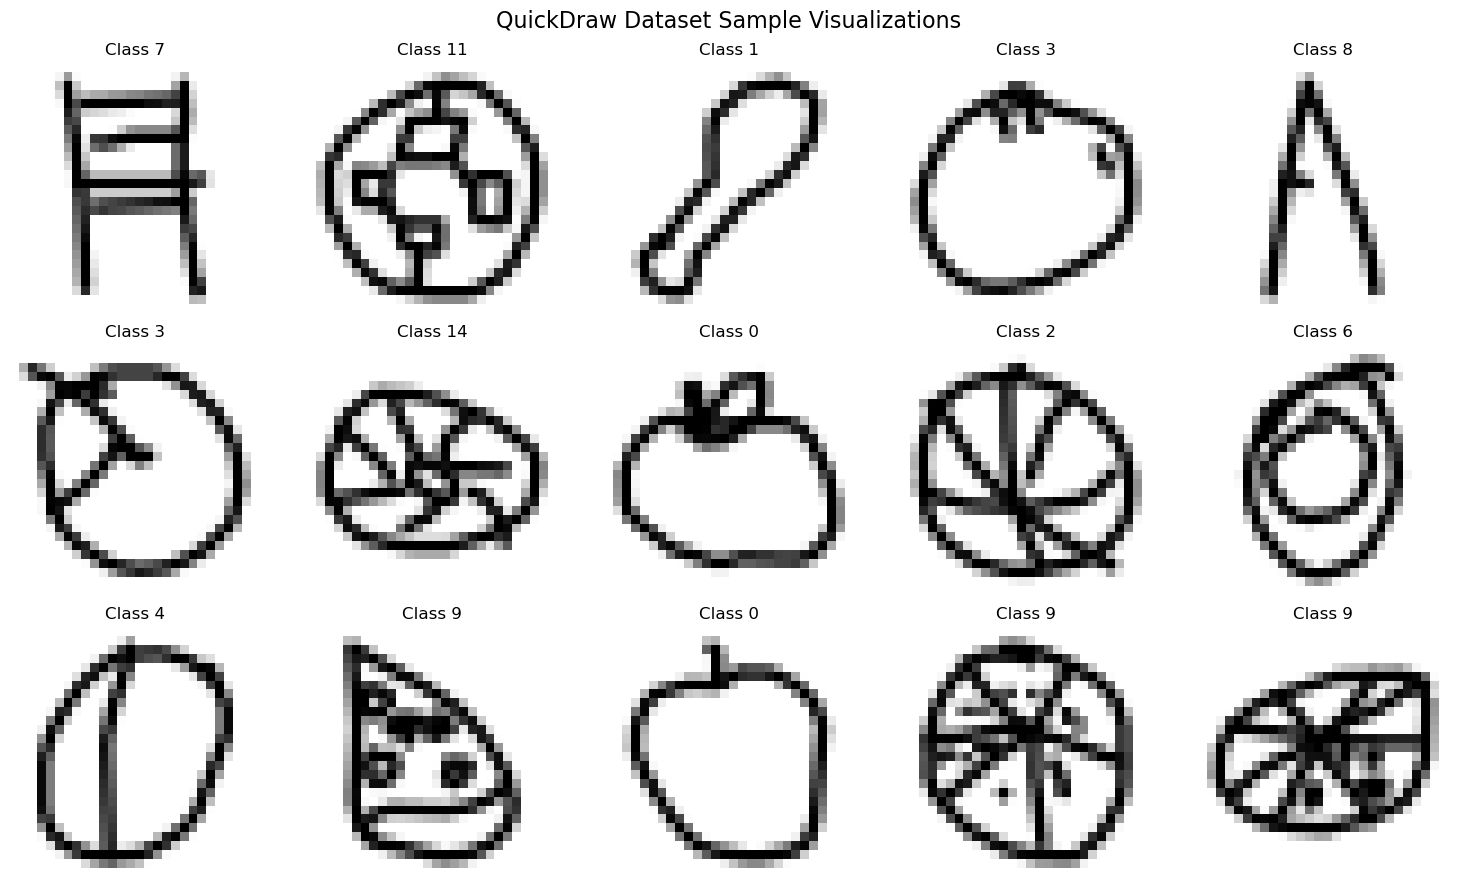

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_dataset_samples(dataset, num_samples_per_row=5, rows=3):
    class_names = getattr(dataset, 'classes', [f"Class {i}" for i in range(15)])
    
    fig, axes = plt.subplots(rows, num_samples_per_row, figsize=(15, 3 * rows))
    fig.suptitle("QuickDraw Dataset Sample Visualizations", fontsize=16)
    
    sample_indices = np.random.choice(len(dataset), rows * num_samples_per_row, replace=False)
    
    for i, ax in enumerate(axes.flatten()):
        idx = sample_indices[i]
        img, label = dataset[idx]
        
        img_np = img.view(28, 28).numpy()
        
        ax.imshow(img_np, cmap='gray_r')
        ax.set_title(class_names[label])
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Show random samples from the training dataset
visualize_dataset_samples(train_dataset)

## Data & Class Exploration
Visualizing the QuickDraw dataset distribution to build early intuition about shape similarity across classes.

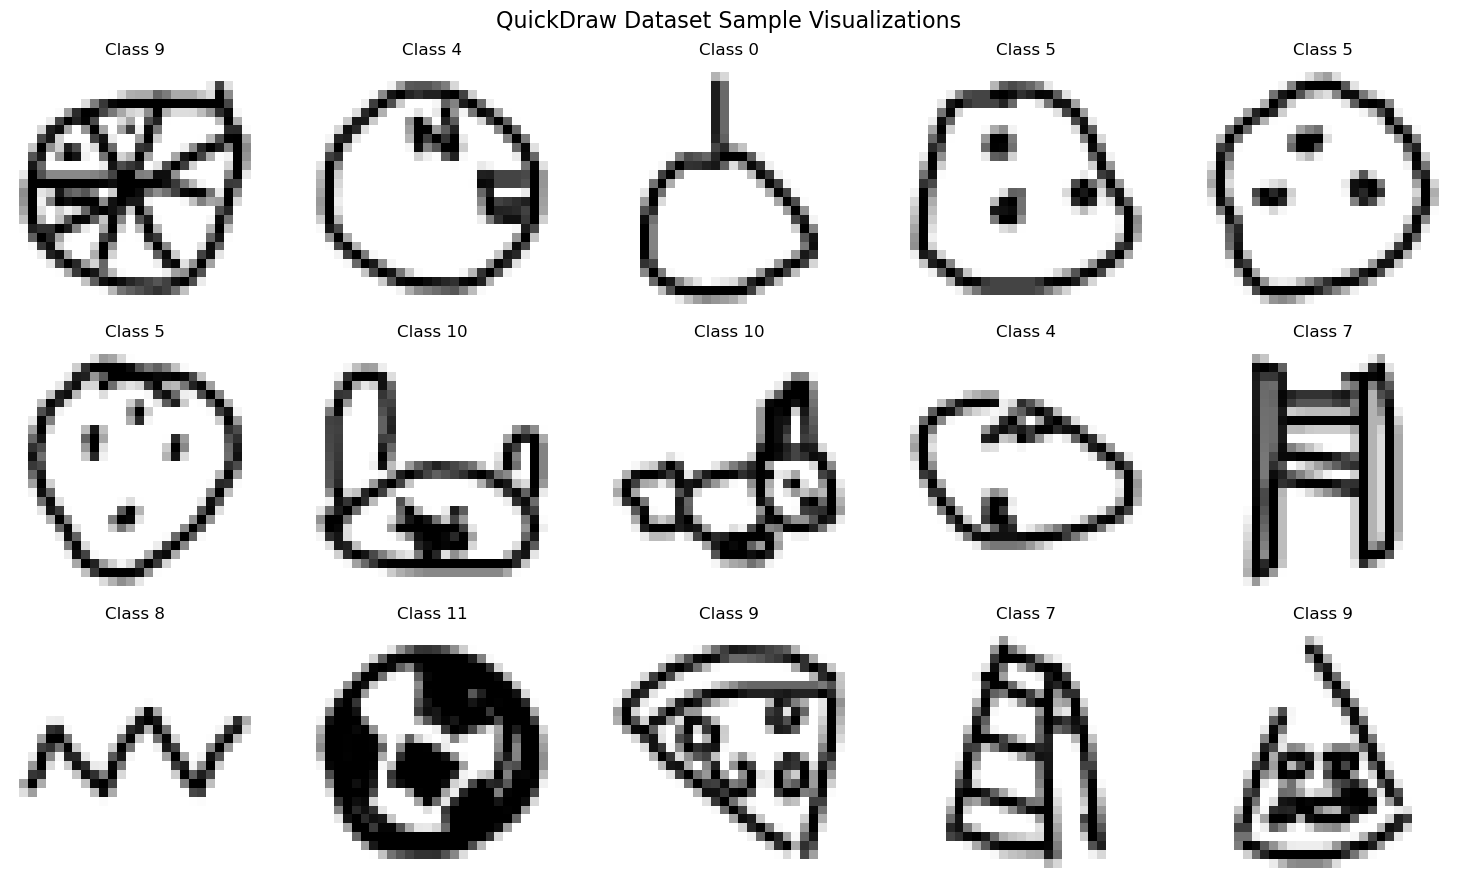

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_dataset_samples(dataset, num_samples_per_row=5, rows=3):
    class_names = getattr(dataset, 'classes', [f"Class {i}" for i in range(15)])
    
    fig, axes = plt.subplots(rows, num_samples_per_row, figsize=(15, 3 * rows))
    fig.suptitle("QuickDraw Dataset Sample Visualizations", fontsize=16)
    
    sample_indices = np.random.choice(len(dataset), rows * num_samples_per_row, replace=False)
    
    for i, ax in enumerate(axes.flatten()):
        idx = sample_indices[i]
        img, label = dataset[idx]
        
        img_np = img.view(28, 28).numpy()
        
        ax.imshow(img_np, cmap='gray_r')
        ax.set_title(class_names[label])
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Show 15 random samples from the training dataset
visualize_dataset_samples(train_dataset, num_samples_per_row=5, rows=3)

In [7]:
len(train_dataset)

x0, y0 = train_dataset[0]
type(x0), x0.shape, y0


(torch.Tensor, torch.Size([784]), tensor(13))

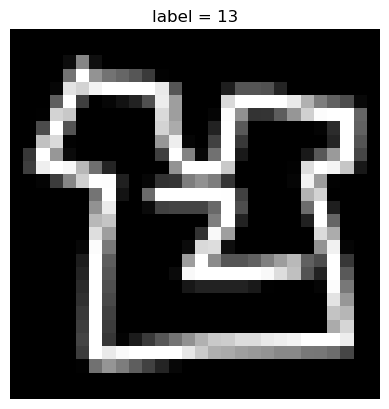

In [8]:
import matplotlib.pyplot as plt

x, y = train_dataset[0]

plt.imshow(x.view(28, 28), cmap="gray")
plt.title(f"label = {int(y)}")
plt.axis("off")
plt.show()


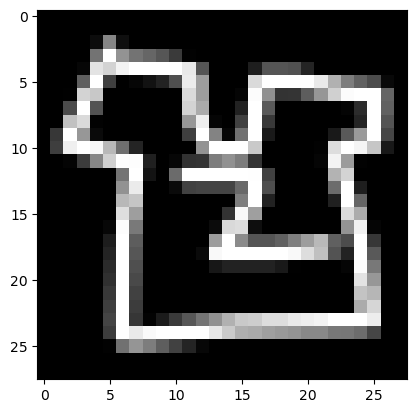

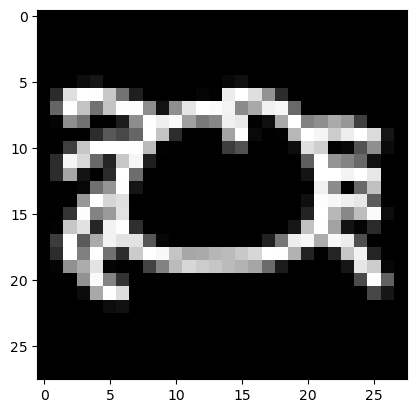

In [9]:
img_5 = train_dataset[0][0].numpy().reshape(28, 28)
plt.imshow(img_5, cmap='gray')
plt.show()
img_0 = train_dataset[1][0].numpy().reshape(28, 28)
plt.imshow(img_0, cmap='gray')
plt.show()

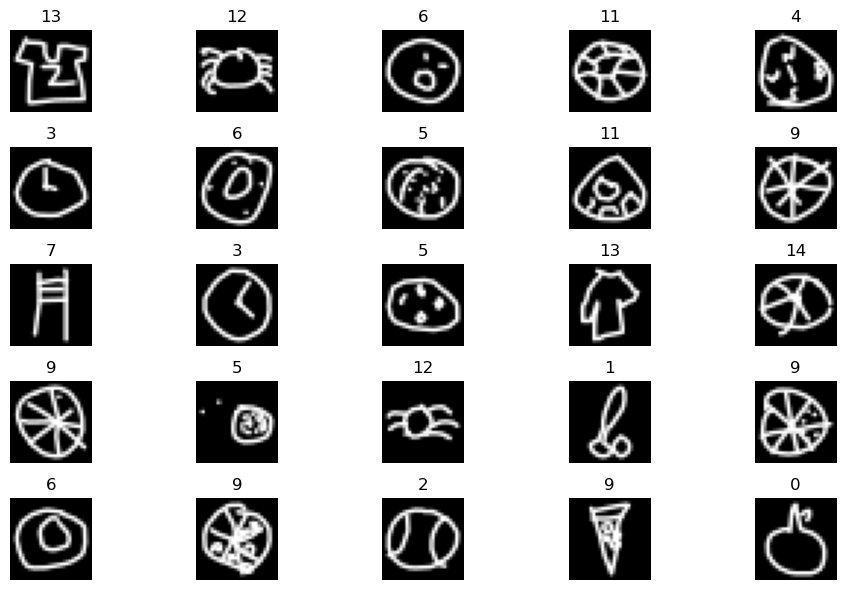

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 5, figsize=(10, 6))
for ax, idx in zip(axes.ravel(), range(25)):
    x, y = train_dataset[idx]
    ax.imshow(x.view(28, 28), cmap="gray")
    ax.set_title(int(y))
    ax.axis("off")
plt.tight_layout()
plt.show()


In [11]:
from collections import Counter

counts = Counter(int(train_dataset[i][1]) for i in range(len(train_dataset)))
counts


Counter({10: 3223,
         5: 3221,
         13: 3216,
         12: 3214,
         3: 3203,
         11: 3201,
         0: 3201,
         9: 3198,
         14: 3198,
         8: 3198,
         2: 3197,
         7: 3193,
         4: 3191,
         1: 3175,
         6: 3171})

In [12]:
x_min, x_max, x_mean = x.min().item(), x.max().item(), x.mean().item()
x_min, x_max, x_mean


(0.0, 1.0, 0.1452130824327469)

In [13]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim

def train_one_epoch(model, criterion, optimizer, dataloader, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)              # logits: (batch, 15)
        loss = criterion(outputs, labels)    # CE expects logits + class indices

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, criterion, dataloader, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def fit(model, criterion, optimizer, train_loader, val_loader, device, epochs, print_every=1):
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, criterion, optimizer, train_loader, device)
        val_loss, val_acc = evaluate(model, criterion, val_loader, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
                  f"val loss {val_loss:.4f} acc {val_acc:.4f}")

    return train_losses, train_accs, val_losses, val_accs


# --- Logistic Regression baseline (for testing the loop) ---
class LogisticRegression(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()
        self.linear = nn.Linear(n_inputs, n_outputs)

    def forward(self, x):
        return self.linear(x)   # logits (NO sigmoid)


criterion = nn.CrossEntropyLoss()
learning_rate = 0.01
model = LogisticRegression(784, 15).to(DEVICE)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

train_losses, train_accs, val_losses, val_accs = fit(
    model, criterion, optimizer,
    train_loader, val_loader,
    DEVICE, epochs=EPOCHS, print_every=1
)


Epoch 1/5 | train loss 2.2501 acc 0.3563 | val loss 1.9586 acc 0.4765


Epoch 2/5 | train loss 1.8104 acc 0.5089 | val loss 1.7145 acc 0.5235


Epoch 3/5 | train loss 1.6385 acc 0.5394 | val loss 1.5981 acc 0.5446


Epoch 4/5 | train loss 1.5469 acc 0.5544 | val loss 1.5296 acc 0.5575


Epoch 5/5 | train loss 1.4889 acc 0.5633 | val loss 1.4847 acc 0.5637


In [14]:
import torch

class MLPTrainer:
    def __init__(self, model, criterion, optimizer, device):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device

    def train(self, dataloader):
        self.model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in dataloader:
            inputs, labels = inputs.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(inputs)           # logits: (batch, num_classes)
            loss = self.criterion(outputs, labels)

            loss.backward()
            self.optimizer.step()

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += batch_size

        return running_loss / total, correct / total

    @torch.no_grad()
    def evaluate(self, dataloader):
        self.model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in dataloader:
            inputs, labels = inputs.to(self.device), labels.to(self.device)

            outputs = self.model(inputs)
            loss = self.criterion(outputs, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += batch_size

        return running_loss / total, correct / total

    @torch.no_grad()
    def predict(self, dataloader, return_probs=False):
        self.model.eval()

        all_preds = []
        all_probs = [] if return_probs else None

        for batch in dataloader:
            # some test loaders yield only inputs
            if isinstance(batch, (list, tuple)) and len(batch) == 2:
                inputs, _ = batch
            else:
                inputs = batch

            inputs = inputs.to(self.device)
            logits = self.model(inputs)
            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu())

            if return_probs:
                probs = torch.softmax(logits, dim=1)
                all_probs.append(probs.cpu())

        all_preds = torch.cat(all_preds, dim=0)

        if return_probs:
            all_probs = torch.cat(all_probs, dim=0)
            return all_preds, all_probs

        return all_preds

    def fit(self, train_loader, epochs, val_loader=None, print_every=1,
        early_stopping=True, patience=5, min_delta=0.0, restore_best=True):
        train_losses, train_accs = [], []
        val_losses, val_accs = [], []

        best_val_acc = float("-inf")
        best_state = None
        no_improve = 0

        for epoch in range(epochs):
            train_loss, train_acc = self.train(train_loader)
            train_losses.append(train_loss)
            train_accs.append(train_acc)

            if val_loader is not None:
                val_loss, val_acc = self.evaluate(val_loader)
                val_losses.append(val_loss)
                val_accs.append(val_acc)

                if (epoch + 1) % print_every == 0:
                    print(f"Epoch {epoch+1}/{epochs} | "
                        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
                        f"val loss {val_loss:.4f} acc {val_acc:.4f}")

                if early_stopping:
                    if val_acc > best_val_acc + min_delta:
                        best_val_acc = val_acc
                        best_state = copy.deepcopy(self.model.state_dict())
                        no_improve = 0
                    else:
                        no_improve += 1
                        if no_improve >= patience:
                            print(f"Early stopping at epoch {epoch+1}. Best val acc: {best_val_acc:.4f}")
                            break
            else:
                if (epoch + 1) % print_every == 0:
                    print(f"Epoch {epoch+1}/{epochs} | "
                        f"train loss {train_loss:.4f} acc {train_acc:.4f}")

        if restore_best and best_state is not None:
            self.model.load_state_dict(best_state)

        return train_losses, train_accs, val_losses, val_accs


In [15]:

trainer = MLPTrainer(model, criterion, optimizer, DEVICE)
trainer.fit(train_loader, epochs=EPOCHS, val_loader=val_loader)


Epoch 1/5 | train loss 1.4488 acc 0.5702 | val loss 1.4526 acc 0.5658


Epoch 2/5 | train loss 1.4188 acc 0.5760 | val loss 1.4286 acc 0.5713


Epoch 3/5 | train loss 1.3955 acc 0.5794 | val loss 1.4095 acc 0.5760


Epoch 4/5 | train loss 1.3769 acc 0.5842 | val loss 1.3944 acc 0.5799


Epoch 5/5 | train loss 1.3613 acc 0.5869 | val loss 1.3814 acc 0.5813


([1.4487720829645792,
  1.418775447845459,
  1.3955332845052084,
  1.376851003964742,
  1.3612941443125406],
 [0.5701666666666667, 0.576, 0.579375, 0.5841666666666666, 0.586875],
 [1.452554968516032,
  1.4286296463012695,
  1.4095488157272338,
  1.3943767461776733,
  1.3813711347579956],
 [0.5658333333333333, 0.57125, 0.576, 0.5799166666666666, 0.58125])

In [16]:
val_loss, val_acc = trainer.evaluate(val_loader)
print(val_loss, val_acc)


1.3813711347579956 0.58125


In [17]:
class PancakeMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, hidden_dim2, out_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim2),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim2, out_dim)  # logits (no activation here)
        )

    def forward(self, x):
        return self.net(x)

In [18]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.001
model = PancakeMLP(784, 1536, 1024, 15, dropout=0.3).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)

In [19]:
num_params = sum(p.numel() for p in model.parameters())
print(num_params)


2795023


In [20]:
EPOCHS = 20
trainer = MLPTrainer(model, criterion, optimizer, DEVICE)
trainer.fit(train_loader, epochs=EPOCHS, val_loader=val_loader,
early_stopping=True, patience=5, min_delta=0.001
)

Epoch 1/20 | train loss 1.1142 acc 0.6353 | val loss 0.9239 acc 0.6925


Epoch 2/20 | train loss 0.8243 acc 0.7264 | val loss 0.7946 acc 0.7312


Epoch 3/20 | train loss 0.6997 acc 0.7622 | val loss 0.7406 acc 0.7519


Epoch 4/20 | train loss 0.6039 acc 0.7919 | val loss 0.7238 acc 0.7662


Epoch 5/20 | train loss 0.5240 acc 0.8188 | val loss 0.7168 acc 0.7727


...

Epoch 9/20 | train loss 0.2984 acc 0.8927 | val loss 0.7971 acc 0.7737


Epoch 10/20 | train loss 0.2572 acc 0.9080 | val loss 0.8701 acc 0.7750


Epoch 11/20 | train loss 0.2245 acc 0.9195 | val loss 0.8581 acc 0.7751


Epoch 12/20 | train loss 0.2066 acc 0.9270 | val loss 0.8896 acc 0.7738
Early stopping at epoch 12. Best val acc: 0.7766


([1.114199253241221,
  0.824256516456604,
  0.6997226177851359,
  0.6038539529641469,
  0.5240360163052877,
  0.4539660512606303,
  0.391425621509552,
  0.336955352584521,
  0.29836142816146216,
  0.25724597680568695,
  0.22450745155413945,
  0.20660581159591676],
 [0.6353333333333333,
  0.726375,
  0.7622291666666666,
  0.7919166666666667,
  0.8188333333333333,
  0.8395,
  0.8614791666666667,
  0.8797916666666666,
  0.8927291666666667,
  0.9080208333333334,
  0.9194791666666666,
  0.927],
 [0.9238802967071533,
  0.7945883331298829,
  0.740574206829071,
  0.7237828815778097,
  0.7167605463663737,
  0.7257467149098714,
  0.7497406921386719,
  0.7394415992101033,
  0.7970893883705139,
  0.8700805155436198,
  0.8581295808156332,
  0.889606016476949],
 [0.6925,
  0.7311666666666666,
  0.7519166666666667,
  0.76625,
  0.7726666666666666,
  0.7683333333333333,
  0.7765833333333333,
  0.7759166666666667,
  0.7736666666666666,
  0.775,
  0.7750833333333333,
  0.7738333333333334])

In [21]:
val_loss, val_acc = trainer.evaluate(val_loader)
print(val_loss, val_acc)


0.7497406921386719 0.7765833333333333


### Pancake Model Evaluation
Analyzing convergence via training curves and pinpointing specific misclassifications via the Confusion Matrix.

Plotting Performance Metrics...


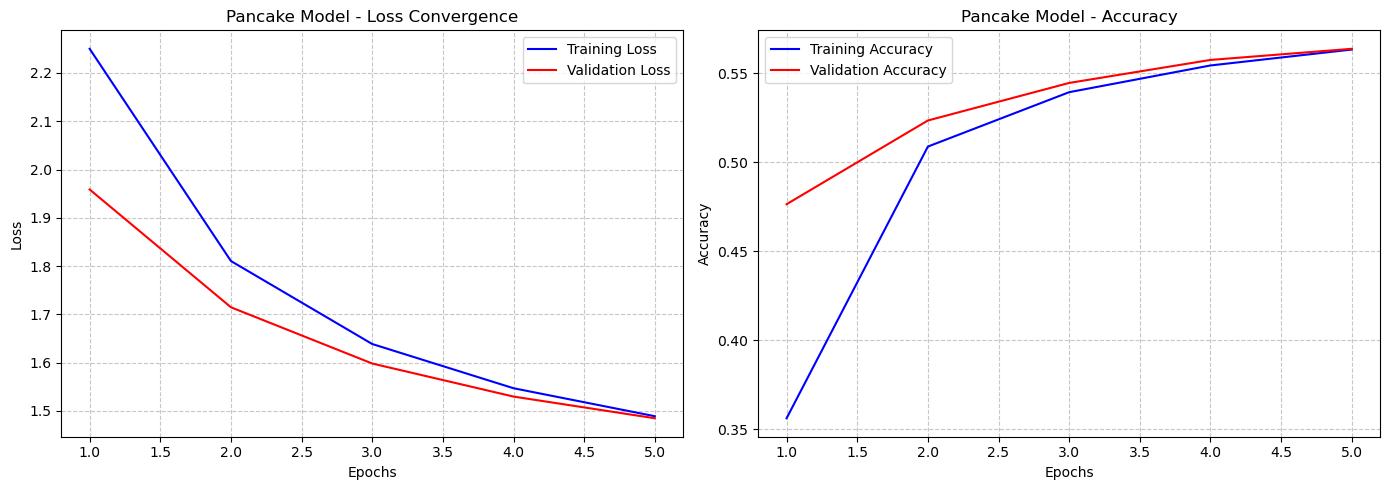

Generating Confusion Matrix...


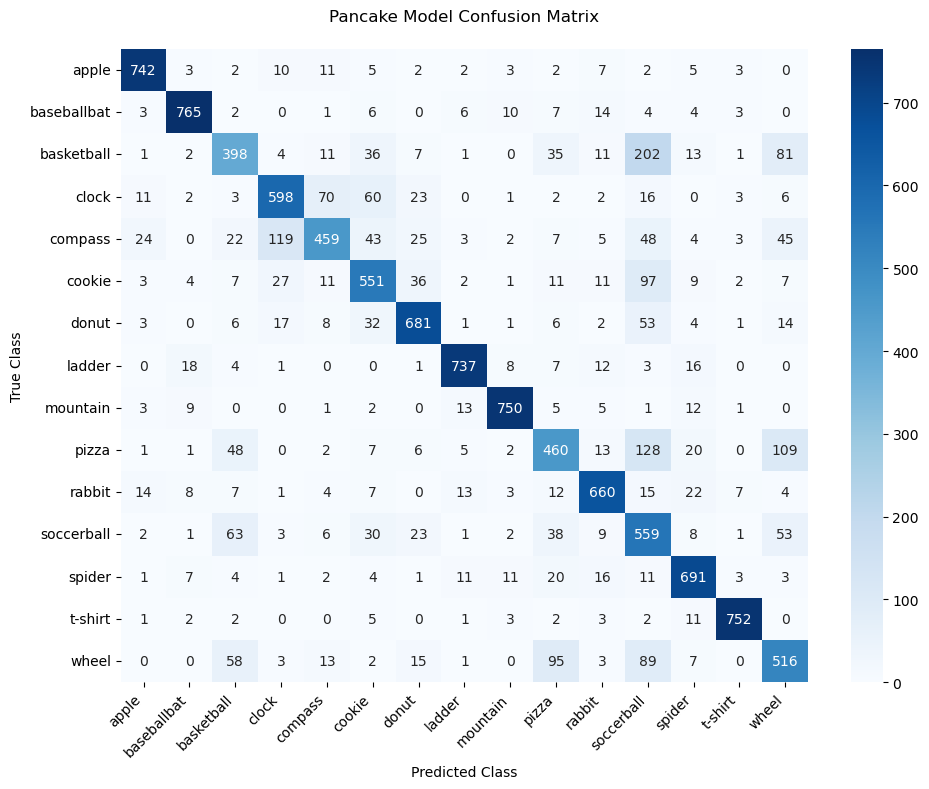

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

def plot_training_history(train_losses, val_losses, train_accs, val_accs, title_prefix="Model"):
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss')
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss')
    ax1.set_title(f'{title_prefix} - Loss Convergence')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy')
    ax2.plot(epochs, val_accs, 'r-', label='Validation Accuracy')
    ax2.set_title(f'{title_prefix} - Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_model_confusion_matrix(eval_model, data_loader, class_names, title="Model Confusion Matrix"):
    eval_model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = eval_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title, pad=20)
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Plotting Performance Metrics...")
try:
    plot_training_history(train_losses, val_losses, train_accs, val_accs, title_prefix="Pancake Model")
except NameError:
    print("Training history not found.")

print("Generating Confusion Matrix...")
try:
    plot_model_confusion_matrix(model, val_loader, train_dataset.dataset.classes, title="Pancake Model Confusion Matrix")
except NameError:
    print("model not found in memory.")

In [23]:
class TowerMLP(nn.Module):
    def __init__(self, in_dim=784, hidden_dim=256, num_layers=6, out_dim=15, dropout=0.2):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.GELU(), nn.Dropout(dropout)]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.GELU(), nn.Dropout(dropout)]
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [24]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.001
tower_model = TowerMLP(in_dim=784, hidden_dim=256, num_layers=6, out_dim=15, dropout=0.2).to(DEVICE)
optimizer = optim.AdamW(tower_model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [25]:
num_params = sum(p.numel() for p in tower_model.parameters())
print(num_params)

536847


In [26]:
EPOCHS = 20
trainer = MLPTrainer(tower_model, criterion, optimizer, DEVICE)
trainer.fit(train_loader, epochs=EPOCHS, val_loader=val_loader,
early_stopping=True, patience=5, min_delta=0.001
)

Epoch 1/20 | train loss 1.2217 acc 0.5964 | val loss 0.9089 acc 0.6968


Epoch 2/20 | train loss 0.9307 acc 0.6916 | val loss 0.8330 acc 0.7214


Epoch 3/20 | train loss 0.8467 acc 0.7177 | val loss 0.7859 acc 0.7368


Epoch 4/20 | train loss 0.7901 acc 0.7373 | val loss 0.7649 acc 0.7467


Epoch 5/20 | train loss 0.7414 acc 0.7544 | val loss 0.7437 acc 0.7527


...

Epoch 17/20 | train loss 0.4416 acc 0.8531 | val loss 0.7115 acc 0.7759


Epoch 18/20 | train loss 0.4231 acc 0.8608 | val loss 0.7066 acc 0.7843


Epoch 19/20 | train loss 0.4169 acc 0.8614 | val loss 0.7230 acc 0.7822


Epoch 20/20 | train loss 0.4054 acc 0.8650 | val loss 0.7185 acc 0.7824
Early stopping at epoch 20. Best val acc: 0.7852


([1.2216846753756205,
  0.9307080812454224,
  0.846746122042338,
  0.7900904684066773,
  0.7414205490748088,
  0.7004590003490448,
  0.6680173125267029,
  0.6375745485623677,
  0.6055173998673757,
  0.5789966351985931,
  0.5584442962010702,
  0.5357643311818441,
  0.5127096443970998,
  0.4905949052969615,
  0.4723413813114166,
  0.45670194760958355,
  0.44163464577992756,
  0.42308015322685244,
  0.41691045689582823,
  0.40541619273026785],
 [0.5964166666666667,
  0.691625,
  0.7177083333333333,
  0.7372916666666667,
  0.7543541666666667,
  0.7669583333333333,
  0.7787916666666667,
  0.7877916666666667,
  0.7993125,
  0.8098125,
  0.8139166666666666,
  0.821375,
  0.8293333333333334,
  0.8367916666666667,
  0.8447708333333334,
  0.8484791666666667,
  0.853125,
  0.8607916666666666,
  0.8613958333333334,
  0.865],
 [0.9089248674710592,
  0.8330231920878093,
  0.7858840363820394,
  0.7649352418581644,
  0.7437438346544901,
  0.7123038687705994,
  0.6976666757265727,
  0.6937490882873535,

In [27]:
inputs, labels = next(iter(train_loader))

In [28]:
outputs = tower_model(inputs.to(DEVICE))
outputs.shape

torch.Size([128, 15])

### Tower Model Evaluation
Analyzing convergence via training curves and pinpointing specific misclassifications via the Confusion Matrix.

Plotting Performance Metrics...


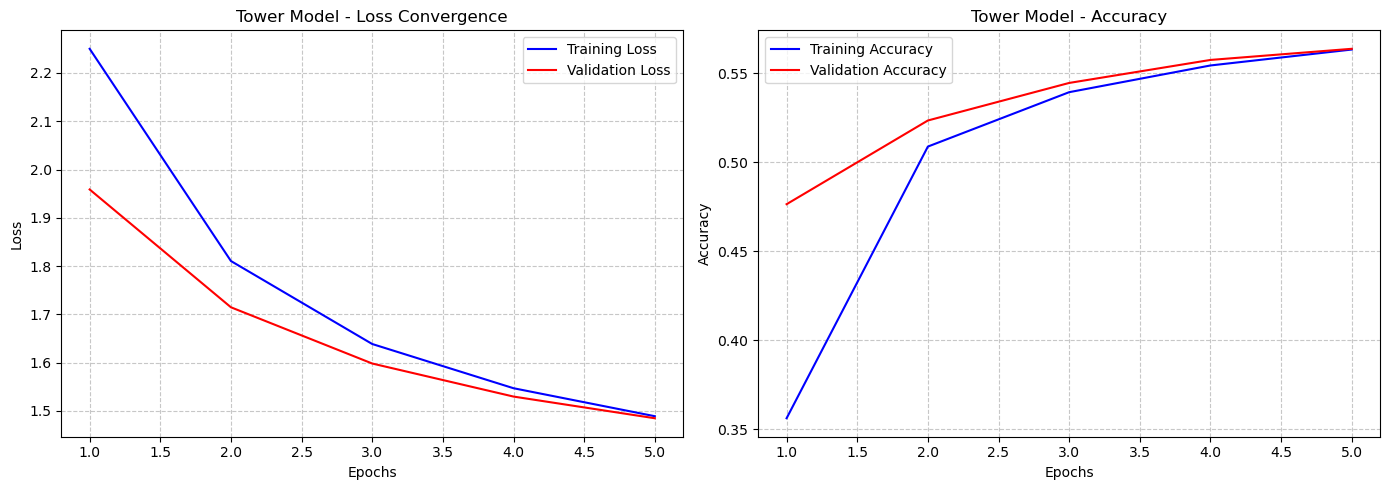

Generating Confusion Matrix...


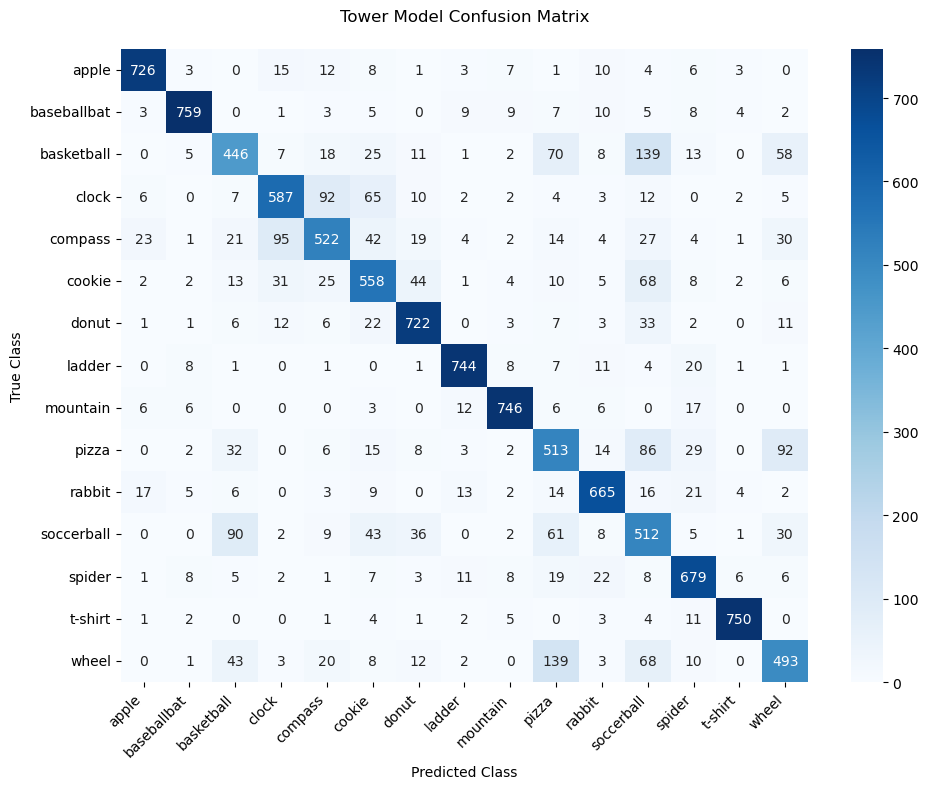

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

def plot_training_history(train_losses, val_losses, train_accs, val_accs, title_prefix="Model"):
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss')
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss')
    ax1.set_title(f'{title_prefix} - Loss Convergence')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy')
    ax2.plot(epochs, val_accs, 'r-', label='Validation Accuracy')
    ax2.set_title(f'{title_prefix} - Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_model_confusion_matrix(eval_model, data_loader, class_names, title="Model Confusion Matrix"):
    eval_model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = eval_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title, pad=20)
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Plotting Performance Metrics...")
try:
    plot_training_history(train_losses, val_losses, train_accs, val_accs, title_prefix="Tower Model")
except NameError:
    print("Training history not found.")

print("Generating Confusion Matrix...")
try:
    plot_model_confusion_matrix(tower_model, val_loader, train_dataset.dataset.classes, title="Tower Model Confusion Matrix")
except NameError:
    print("tower_model not found in memory.")

In [30]:
loss = criterion(outputs, labels.to(DEVICE))
loss.item()

0.2880595922470093

In [31]:
val_loss, val_acc = trainer.evaluate(val_loader)
print(val_loss, val_acc)


0.6951153953870137 0.7851666666666667


In [32]:
class ChampionMLP(nn.Module):
    def __init__(self, in_dim=784, out_dim=15, dropout=0.2):
        super().__init__()
        # Funnel Architecture: Start wide, get narrow
        self.net = nn.Sequential(
            # Layer 1
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            
            # Layer 2
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            
            # Layer 3
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
            
            # Layer 4
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout),
            
            # Output Layer
            nn.Linear(128, out_dim)
        )

    def forward(self, x):
        return self.net(x)


In [33]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.003
champion_model = ChampionMLP(in_dim=784, out_dim=15, dropout=0.3).to(DEVICE)
optimizer = optim.AdamW(champion_model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [34]:
num_params = sum(p.numel() for p in champion_model.parameters())
print(num_params)

833551


In [35]:
EPOCHS = 50
trainer = MLPTrainer(champion_model, criterion, optimizer, DEVICE)
trainer.fit(train_loader, epochs=EPOCHS, val_loader=val_loader,
early_stopping=True, patience=5, min_delta=0.001
)

Epoch 1/50 | train loss 1.1172 acc 0.6305 | val loss 0.8709 acc 0.7052


Epoch 2/50 | train loss 0.8909 acc 0.7039 | val loss 0.7910 acc 0.7289


Epoch 3/50 | train loss 0.7950 acc 0.7356 | val loss 0.7421 acc 0.7532


Epoch 4/50 | train loss 0.7253 acc 0.7587 | val loss 0.7025 acc 0.7643


Epoch 5/50 | train loss 0.6660 acc 0.7777 | val loss 0.6939 acc 0.7727


...

Epoch 12/50 | train loss 0.4217 acc 0.8574 | val loss 0.6968 acc 0.7903


Epoch 13/50 | train loss 0.3983 acc 0.8663 | val loss 0.7164 acc 0.7853


Epoch 14/50 | train loss 0.3817 acc 0.8719 | val loss 0.7095 acc 0.7894


Epoch 15/50 | train loss 0.3561 acc 0.8798 | val loss 0.7002 acc 0.7906
Early stopping at epoch 15. Best val acc: 0.7897


([1.1172079496383667,
  0.8908842441240946,
  0.7949782826105753,
  0.7253181660970052,
  0.6660333748658498,
  0.6162614933649699,
  0.5752118704319,
  0.5412374274730682,
  0.5044714736938477,
  0.4745140585899353,
  0.4484346990585327,
  0.42174954187870023,
  0.3982918709119161,
  0.38172125347455343,
  0.3561410477558772],
 [0.6305416666666667,
  0.7038958333333334,
  0.7355833333333334,
  0.7587291666666667,
  0.7777291666666667,
  0.7962083333333333,
  0.8067708333333333,
  0.8198958333333334,
  0.8307291666666666,
  0.840125,
  0.849125,
  0.8574166666666667,
  0.8662708333333333,
  0.8719375,
  0.87975],
 [0.870883262793223,
  0.7909645139376322,
  0.7420870609283448,
  0.7024726327260336,
  0.6938791047732036,
  0.6887843551635742,
  0.6676896967887879,
  0.659067662080129,
  0.687295518398285,
  0.6642390438715617,
  0.6938250312805175,
  0.6968162293434144,
  0.7164302995999654,
  0.7095063405036927,
  0.7002029633522033],
 [0.7051666666666667,
  0.7289166666666667,
  0.753

In [36]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...


Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [37]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 2,795,023
  ✅ Parameter count is within limits.


### 🚀 MLPTrainerV2 with Scheduler

In [38]:
class MLPTrainerV2:
    def __init__(self, model, criterion, optimizer, device, scheduler=None):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device

    def train(self, dataloader):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in dataloader:
            inputs, labels = inputs.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(inputs)           
            loss = self.criterion(outputs, labels)

            loss.backward()
            self.optimizer.step()

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += batch_size

        return running_loss / total, correct / total

    @torch.no_grad()
    def evaluate(self, dataloader):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in dataloader:
            inputs, labels = inputs.to(self.device), labels.to(self.device)

            outputs = self.model(inputs)
            loss = self.criterion(outputs, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += batch_size

        return running_loss / total, correct / total

    def fit(self, train_loader, epochs, val_loader=None, early_stopping=False, patience=5, min_delta=0.001, print_every=1):
        train_losses, train_accs = [], []
        val_losses, val_accs = [], []
        
        best_acc = 0.0 
        epochs_no_improve = 0

        for epoch in range(epochs):
            train_loss, train_acc = self.train(train_loader)
            train_losses.append(train_loss)
            train_accs.append(train_acc)

            if val_loader is not None:
                val_loss, val_acc = self.evaluate(val_loader)
                val_losses.append(val_loss)
                val_accs.append(val_acc)
                
                if self.scheduler is not None:
                    if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                        self.scheduler.step(val_loss)
                    else:
                        self.scheduler.step()

                if (epoch + 1) % print_every == 0:
                    current_lr = self.optimizer.param_groups[0]['lr']
                    print(f"Epoch {epoch+1}/{epochs} | LR: {current_lr:.5f} | "
                          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
                          f"val loss {val_loss:.4f} acc {val_acc:.4f}")
                          
                if early_stopping:
                    if val_acc > best_acc + min_delta:  
                        best_acc = val_acc
                        epochs_no_improve = 0
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            print(f"Early stopping at epoch {epoch+1}. Best val acc: {best_acc:.4f}")
                            break
            else:
                if (epoch + 1) % print_every == 0:
                    current_lr = self.optimizer.param_groups[0]['lr']
                    print(f"Epoch {epoch+1}/{epochs} | LR: {current_lr:.5f} | "
                          f"train loss {train_loss:.4f} acc {train_acc:.4f}")

        return train_losses, train_accs, val_losses, val_accs


### 🏆 Training ChampionMLP with MLPTrainerV2

In [39]:
champion_model = ChampionMLP(in_dim=784, out_dim=15, dropout=0.2).to(DEVICE) 

# 1. Setup Optimizer
learning_rate = 0.005 
optimizer = optim.AdamW(champion_model.parameters(), lr=learning_rate, weight_decay=1e-4)

# 2. Setup Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=2
)

# 3. Train using MLPTrainerV2 WITH Augmentation!
EPOCHS = 60 # Might need more epochs since training is harder now
trainer_v2 = MLPTrainerV2(champion_model, criterion, optimizer, DEVICE, scheduler=scheduler)

print("Starting Champion Training with Scheduler & Data Augmentation...")
train_losses, train_accs, val_losses, val_accs = trainer_v2.fit(
    train_loader, 
    epochs=EPOCHS, 
    val_loader=val_loader,
    early_stopping=True, 
    patience=7, # Reaching higher accuracy with augmentation is slower, be patient!
    min_delta=0.001
)

Starting Champion Training with Scheduler & Data Augmentation...


Epoch 1/60 | LR: 0.00500 | train loss 1.0718 acc 0.6455 | val loss 0.8659 acc 0.7102


Epoch 2/60 | LR: 0.00500 | train loss 0.8413 acc 0.7195 | val loss 0.7908 acc 0.7336


Epoch 3/60 | LR: 0.00500 | train loss 0.7373 acc 0.7526 | val loss 0.7329 acc 0.7541


Epoch 4/60 | LR: 0.00500 | train loss 0.6547 acc 0.7808 | val loss 0.6961 acc 0.7682


...

Epoch 15/60 | LR: 0.00125 | train loss 0.1678 acc 0.9422 | val loss 0.9159 acc 0.7851


Epoch 16/60 | LR: 0.00125 | train loss 0.1482 acc 0.9497 | val loss 0.9667 acc 0.7873


Epoch 17/60 | LR: 0.00063 | train loss 0.1375 acc 0.9532 | val loss 1.0063 acc 0.7862


Epoch 18/60 | LR: 0.00063 | train loss 0.1222 acc 0.9576 | val loss 0.9973 acc 0.7876


Epoch 19/60 | LR: 0.00063 | train loss 0.1121 acc 0.9628 | val loss 1.0240 acc 0.7868
Early stopping at epoch 19. Best val acc: 0.7866


### 🚀 Fast DataLoader Augmentation

In [40]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class AugmentedDataset(Dataset):
    def __init__(self, original_dataset):
        self.dataset = original_dataset
        # Define the transform. We do it here so it runs on CPU before the GPU sees it!
        self.augment = transforms.RandomAffine(degrees=10, translate=(0.05, 0.05))

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # We only augment the training data, NOT validation or test data!
        # Your dataset doesn't have an explicit mode accessible like this if it's a Subset
        # We will assume this is ONLY used to wrap a train subset.
        x, y = self.dataset[idx]
        
        # The original x is a flattened 1D tensor (784,). 
        # Reshape to a 2D image (1, 28, 28) for the transform
        x_img = x.view(1, 28, 28)
        x_aug = self.augment(x_img)
        
        # Flatten it back to (784,) for the MLP
        return x_aug.view(-1), y

# --- 1. Wrap your existing train_dataset with the Augmenter ---
augmented_train_dataset = AugmentedDataset(train_dataset)

# --- 2. Create a new DataLoader using the augmented dataset ---
# Set num_workers=2 or 4 to let your Mac's CPU cores handle the rotations in parallel!
aug_train_loader = DataLoader(
    augmented_train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0, # Using CPU threads to preprocess
    pin_memory=True # Speeds up transfer to MPS
)

print("Augmented Training Loader Ready! CPU will handle rotations.")

Augmented Training Loader Ready! CPU will handle rotations.


### 🏆 Train ChampionMLP via Augmented DataLoader

In [47]:
champion_model = ChampionMLP(in_dim=784, out_dim=15, dropout=0.1).to(DEVICE) 

# 1. Setup Optimizer
learning_rate = 0.005
optimizer = optim.AdamW(champion_model.parameters(), lr=learning_rate, weight_decay=1e-5)

# 2. Setup Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=4, 
    
)

# 3. Train using MLPTrainerV2 WITH Augmentation DataLoader!
EPOCHS = 40 
trainer_v2 = MLPTrainerV2(champion_model, criterion, optimizer, DEVICE, scheduler=scheduler)

print("Starting Champion Training with Augmented DataLoader...")
train_losses, train_accs, val_losses, val_accs = trainer_v2.fit(
    aug_train_loader,
    epochs=EPOCHS, 
    val_loader=val_loader,
    early_stopping=True, 
    patience=7,
    min_delta=0.001
)

Starting Champion Training with Augmented DataLoader...
Epoch 1/40 | LR: 0.00500 | train loss 1.1337 acc 0.6187 | val loss 0.8372 acc 0.7216
Epoch 2/40 | LR: 0.00500 | train loss 0.9192 acc 0.6904 | val loss 0.7788 acc 0.7410
Epoch 3/40 | LR: 0.00500 | train loss 0.8356 acc 0.7196 | val loss 0.7353 acc 0.7512
Epoch 4/40 | LR: 0.00500 | train loss 0.7736 acc 0.7412 | val loss 0.6675 acc 0.7788
Epoch 5/40 | LR: 0.00500 | train loss 0.7303 acc 0.7538 | val loss 0.6409 acc 0.7847
Epoch 6/40 | LR: 0.00500 | train loss 0.7016 acc 0.7657 | val loss 0.6312 acc 0.7867
Epoch 7/40 | LR: 0.00500 | train loss 0.6724 acc 0.7740 | val loss 0.6091 acc 0.7980
Epoch 8/40 | LR: 0.00500 | train loss 0.6495 acc 0.7827 | val loss 0.5900 acc 0.8053
Epoch 9/40 | LR: 0.00500 | train loss 0.6331 acc 0.7872 | val loss 0.5780 acc 0.8073
Epoch 10/40 | LR: 0.00500 | train loss 0.6117 acc 0.7946 | val loss 0.5814 acc 0.8036
Epoch 11/40 | LR: 0.00500 | train loss 0.5975 acc 0.7991 | val loss 0.5636 acc 0.8137
Epoch 1

In [48]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(champion_model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [49]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(champion_model)


Model Statistics:
  Total Parameters: 833,551
  ✅ Parameter count is within limits.


### Champion Model Evaluation
Analyzing convergence via training curves and pinpointing specific misclassifications via the Confusion Matrix.

Plotting Performance Metrics...


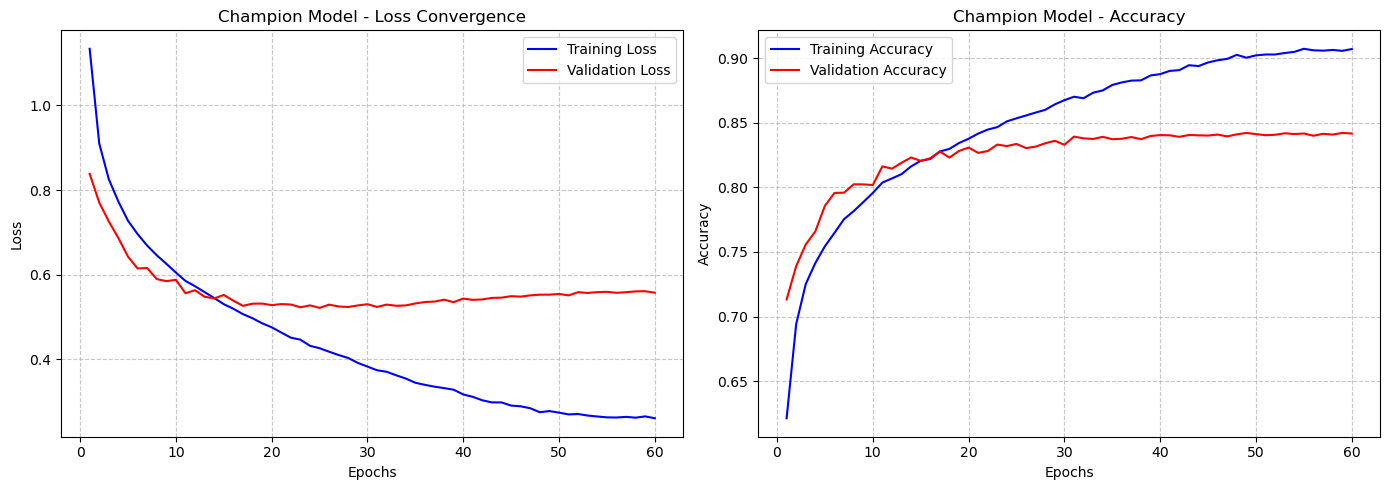

Generating Confusion Matrix...


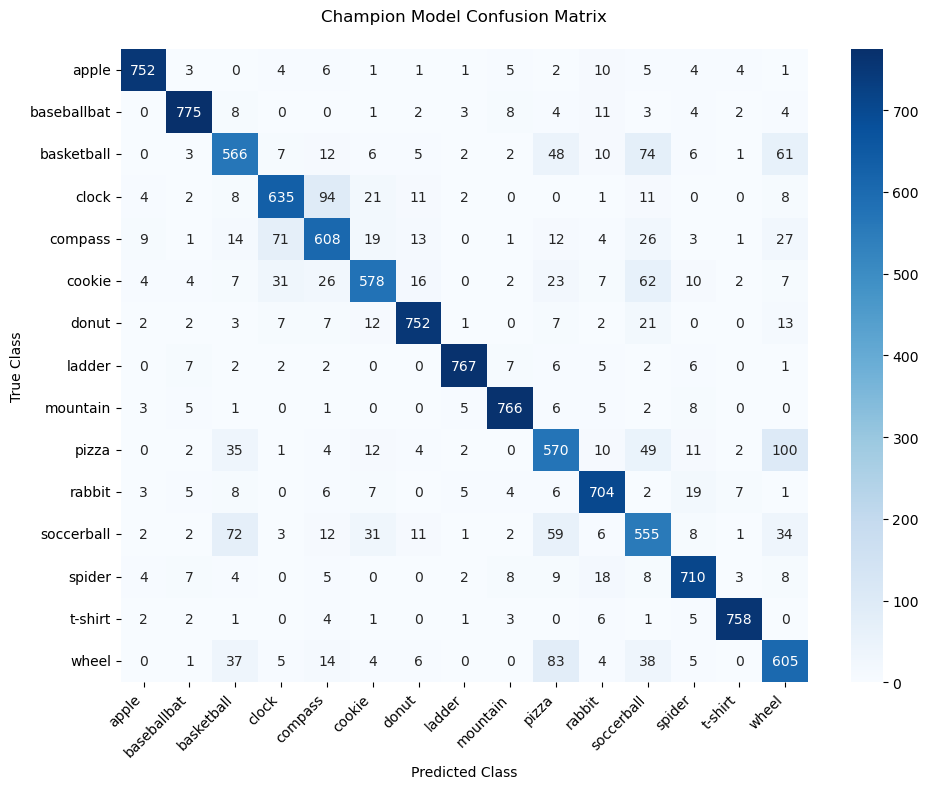

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

def plot_training_history(train_losses, val_losses, train_accs, val_accs, title_prefix="Model"):
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss')
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss')
    ax1.set_title(f'{title_prefix} - Loss Convergence')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy')
    ax2.plot(epochs, val_accs, 'r-', label='Validation Accuracy')
    ax2.set_title(f'{title_prefix} - Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_model_confusion_matrix(model, data_loader, class_names, title="Model Confusion Matrix"):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title, pad=20)
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Plotting Performance Metrics...")
try:
    plot_training_history(train_losses, val_losses, train_accs, val_accs, title_prefix="Champion Model")
except NameError:
    print("Training history not found.")

print("Generating Confusion Matrix...")
try:
    plot_model_confusion_matrix(champion_model, val_loader, train_dataset.dataset.classes, title="Champion Model Confusion Matrix")
except NameError:
    print("champion_model not found in memory.")

In [50]:
import torch
import os
# Save the Champion Model Weights for submission
save_path = "champion_weights.pth"
torch.save(champion_model.state_dict(), save_path)
print(f"✅ Champion weights successfully saved to {save_path}!")

✅ Champion weights successfully saved to champion_weights.pth!
